<a href="https://colab.research.google.com/github/SquirrelCat235/AI-Budget-Analyser/blob/main/Monthly_Temp_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🌡️ Detecting Anomalies in temperature

In [ ]:
residuals_arma = residuals(fit)
res_mat = matrix(residuals_arma, ncol=1)

In [ ]:
install.packages("isotree")
library(isotree)

iso_model <- isolation.forest(res_mat, ntrees=100)
scores <- predict(iso_model, res_mat)

threshold <- quantile(scores, 0.95)
anomalies_hist <- scores > threshold

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘RhpcBLASctl’




In [ ]:
forecast_mean <- as.numeric(Y_future_ts)

hist_mean <- mean(data_temp)
hist_sd <- sd(data_temp)

upper_bound <- hist_mean + 2*hist_sd
lower_bound <- hist_mean - 2*hist_sd

anomalies_future <- (forecast_mean > upper_bound) |
                    (forecast_mean < lower_bound)

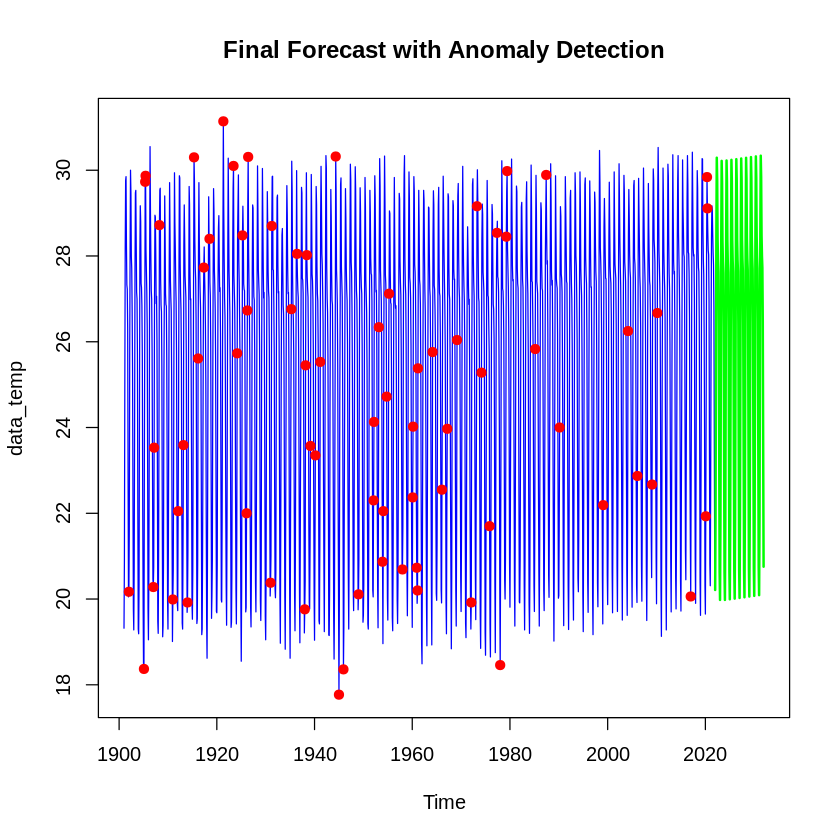

In [ ]:
plot(data_temp,
     xlim=c(start(data_temp)[1], 2032),
     col="blue",
     main="Final Forecast with Anomaly Detection")

# Forecast
lines(Y_future_ts, col="green", lwd=2)

# Historical anomalies
points(time(data_temp)[anomalies_hist],
       data_temp[anomalies_hist],
       col="red", pch=19)

# Future anomalies
points(time(Y_future_ts)[anomalies_future],
       forecast_mean[anomalies_future],
       col="purple", pch=19)

##🚨 Anomaly Trend Over Time

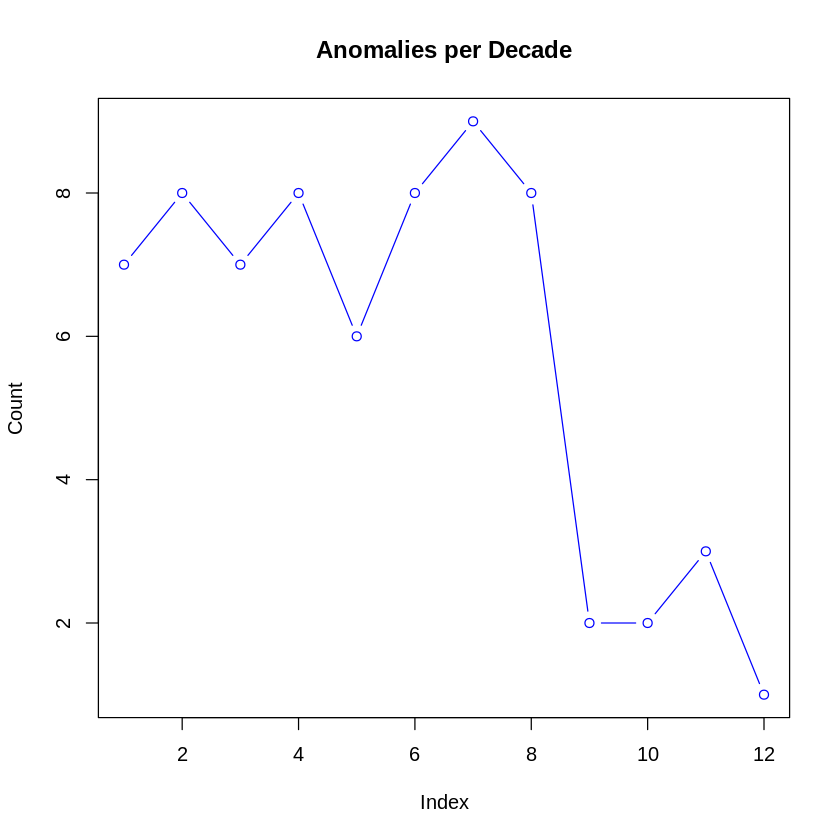

In [ ]:
time_index =time(Month_temp)
decade =floor(time_index/10)*10

anomaly_count =tapply(anomalies_hist, decade, sum)

plot(anomaly_count, type="b", col="blue",
     main="Anomalies per Decade",
     ylab="Count")

Interpretation: The anomaly count shows fluctuating behavior across decades, with a peak in the mid-period indicating high variability. Although the frequency of anomalies appears to decline in recent decades, this may suggest a shift in baseline climate patterns, where extreme temperatures are becoming more normalized rather than less frequent.

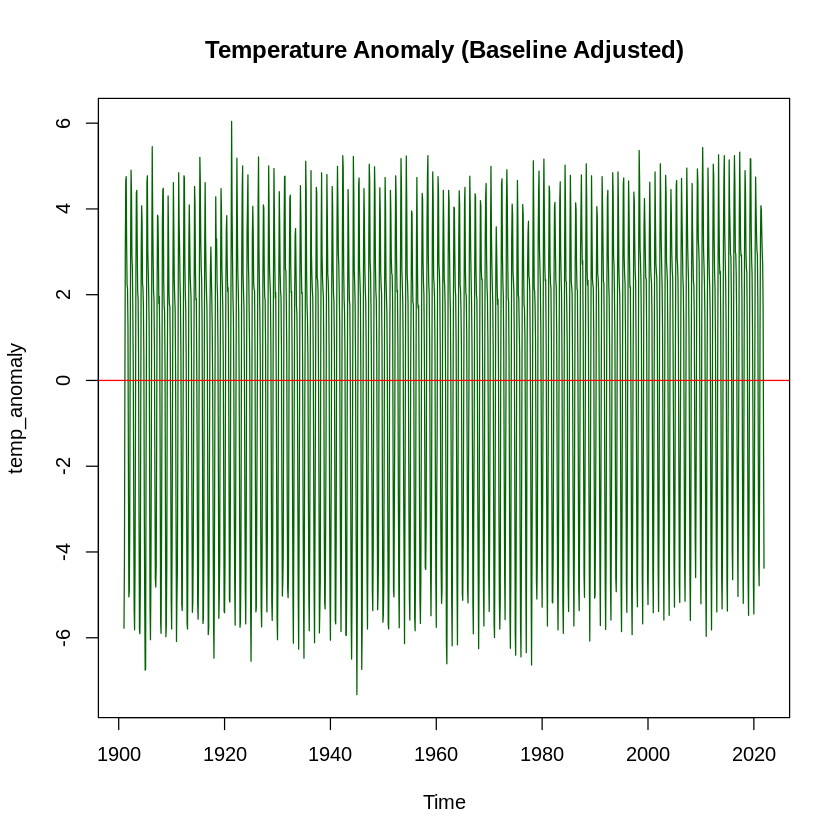

In [ ]:
baseline <- mean(data_temp[1:360])  # first 30 years

temp_anomaly <- data_temp - baseline

plot(temp_anomaly, col="darkgreen",
     main="Temperature Anomaly (Baseline Adjusted)")
abline(h=0, col="red")

Observations: The baseline-adjusted temperature anomalies oscillate around zero, reflecting natural seasonal variations. However, the presence of frequent positive anomalies in recent years suggests a gradual shift toward higher temperatures relative to the historical baseline.

This indicates that while seasonal patterns remain consistent, the underlying climate baseline may be shifting upward.

## Detecting Structural Breaks

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)




	 Optimal (m+1)-segment partition: 

Call:
breakpoints.formula(formula = data_temp ~ 1)

Breakpoints at observation number:
                            
m = 1                   1167
m = 2           603     1167
m = 3       543     939 1167
m = 4       482 718 939 1167
m = 5   219 482 718 939 1167

Corresponding to breakdates:
                                                
m = 1                                    1998(3)
m = 2                   1951(3)          1998(3)
m = 3           1946(3)          1979(3) 1998(3)
m = 4           1941(2) 1960(10) 1979(3) 1998(3)
m = 5   1919(3) 1941(2) 1960(10) 1979(3) 1998(3)

Fit:
                                       
m   0     1     2     3     4     5    
RSS 17163 17075 17063 17060 17057 17055
BIC  7721  7728  7742  7756  7771  7785

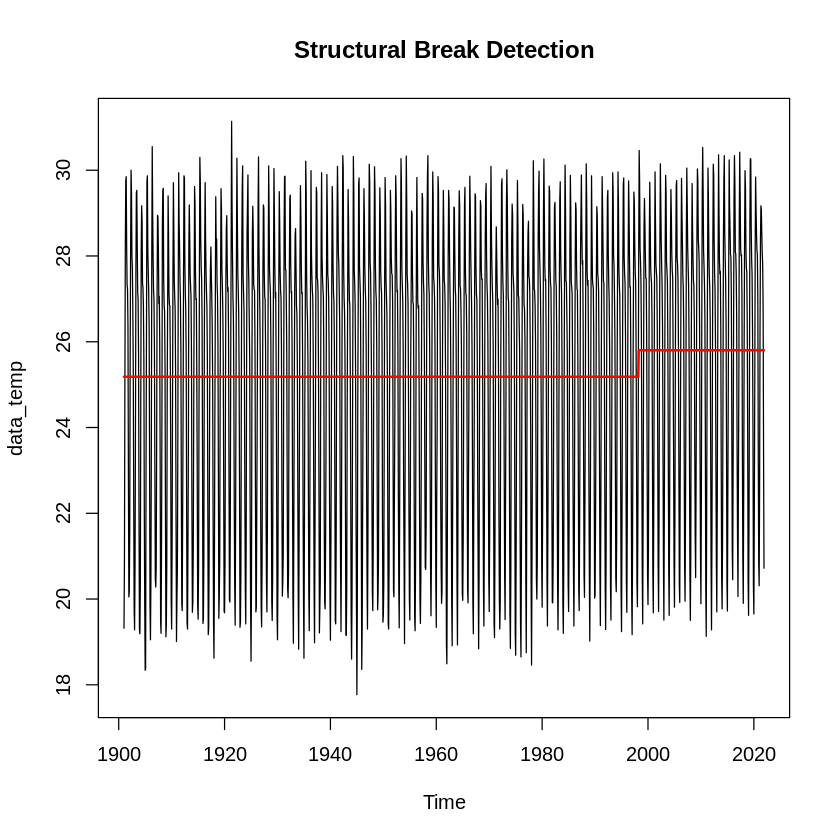

In [ ]:
install.packages("strucchange")
library(strucchange)

bp <- breakpoints(data_temp ~ 1)

summary(bp)

plot(data_temp, main="Structural Break Detection")
lines(fitted(bp, breaks=1), col="red", lwd=2)


Observations: The structural break analysis reveals a significant shift in the mean temperature around the early 2000s. This indicates a change in the underlying climate regime, where the baseline temperature level has increased.

Such a shift suggests that recent temperature patterns are not merely due to short-term variability but reflect a long-term transformation in climate behavior.